# Phaeocystis pathway analysis
In this notebook, we'll analyze the pathways expressed by Phaeocystis globosa. Specifically, we're interested in cyclic patterns, carbohydrate production, etc. 
First we'll extract transcripts annotated to Phaeocystis globosa, combine them with functional information, gene expression info and metadata.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np
import seaborn as sns
import time
from goatools.obo_parser import GODag
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from bs4 import BeautifulSoup

## Data preparation

In [3]:
# Read Phaglo1 gene expression data
expression = pd.read_csv("../data/phaglo1_mapping/gene_expression/gene_tpm.tsv", sep="\t")
# Reshape to long format
expression = expression.melt(id_vars=["gene_id"], var_name="sample", value_name="TPM")
# Only retain samples from station 130
expression = expression[expression['sample'].str.contains('130_')]
expression.head()

,gene_id,sample,TPM
674919,gene_1,130_1,0.000000
674920,gene_10,130_1,11.162677
674921,gene_100,130_1,0.000000
674922,gene_1000,130_1,2.697723
674923,gene_10000,130_1,0.000000


In [4]:
# Read in the functional annotation data
functional_annotation = pd.read_csv("../data/phaglo1_mapping/annotation/gene_functions.tsv", sep="\t")

functional_annotation.head()

,gene_id,n_proteins,EC,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,CAZy_desc,signalp
0,gene_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,gene_10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,gene_100,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,gene_1000,2,NaN,NaN,NaN,NaN,NaN,NaN,IPR005069;IPR029044,NaN,NaN,NaN,NaN,False
4,gene_10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [5]:
functional_annotation.columns

Index(['gene_id', 'n_proteins', 'EC', 'KEGG_def', 'KEGG_pathway', 'GO',
       'GO_name', 'GO_type', 'IPR', 'KOG', 'KOG_desc', 'CAZy', 'CAZy_desc',
       'signalp'],
      dtype='object')

In [6]:
# Read in the environmental data
env_data = pd.read_csv('../data/samples_env.csv', index_col=0)
# Read in primary production data
PP_data = pd.read_csv('../data/raw/LabSTAF/labstaf_combined_data.csv')
## Combine Station and Sample columns into one station_sample column
PP_data['Station'] = PP_data['Station'].astype(str) + '_' + PP_data['Sample'].astype(str)

# Merge PP_data with env and transcript data
env_data = env_data.merge(PP_data[['Station', 'PP']], on=['Station'], how='inner')

# Rename station column
env_data.rename(columns={'Station': 'sample'}, inplace=True)

print(env_data.columns)

Index(['sample', 'StationPrefix', 'StationSuffix', 'Latitude', 'Longitude',
       'Date', 'day_moment', 'day_length', 'Temperature', 'Salinity',
       'Conductivity', 'Depth', 'Oxygen', 'Fluorescence', 'NH4', 'NO2', 'NO3',
       'NOX', 'PO4', 'Si', 'TEP', 'sea_surface_height_above_sea_level',
       'surface_baroclinic_sea_water_velocity', 'PP'],
      dtype='object')


In [7]:
# Create a dataframe containing the sample names, functional annotation categories of interest and TPL
functional_columns = ['gene_id', 'KEGG_def', 'KEGG_pathway', 'GO', 'GO_name', 'GO_type', 'IPR', 'KOG', 'KOG_desc', 'CAZy', 'CAZy_desc', 'signalp']
data = functional_annotation[functional_columns].merge(expression, on='gene_id', how='inner')
data = data.merge(env_data, on='sample', how='inner')

data.head()

,gene_id,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
0,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832000,-1.802973,0.543319,356.76
1,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172000,-1.069393,0.562920,231.00
2,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.34,0.37,17.44,17.81,0.05,14.30,1326.340000,-0.290541,0.361021,224.76
3,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.02,0.35,15.94,16.29,0.05,13.36,1083.648000,1.187761,0.338537,235.20
4,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.40,0.30,17.13,17.43,0.05,12.82,1728.945333,2.587380,0.865567,411.48


## KEGG Pathways

In [8]:
# Remove the 'ko:' prefix and split multiple KOs
data_KEGG = data[data['KEGG_pathway'].notna()].copy()
data_KEGG['KEGG_pathway'] = data_KEGG['KEGG_pathway'].str.split(';')

# Explode the dataframe to have one KO per row (duplicating TPL values accordingly)
data_KEGG = data_KEGG.explode('KEGG_pathway')

# Inspect the data
data_KEGG.head()

,gene_id,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
175,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832,-1.802973,0.543319,356.76
175,gene_10003,Ferredoxin--NADP(+) reductase.,Porphyrin and chlorophyll metabolism,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832,-1.802973,0.543319,356.76
176,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172,-1.069393,0.562920,231.00
176,gene_10003,Ferredoxin--NADP(+) reductase.,Porphyrin and chlorophyll metabolism,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172,-1.069393,0.562920,231.00
177,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.34,0.37,17.44,17.81,0.05,14.30,1326.340,-0.290541,0.361021,224.76


In [9]:
# Extract unique pathway IDs
unique_pathways = data_KEGG['KEGG_pathway'].unique()
len(unique_pathways)

111

In [10]:
data_KEGG.iloc[:, 1:]

,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,CAZy_desc,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
175,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832000,-1.802973,0.543319,356.76
175,Ferredoxin--NADP(+) reductase.,Porphyrin and chlorophyll metabolism,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832000,-1.802973,0.543319,356.76
176,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172000,-1.069393,0.562920,231.00
176,Ferredoxin--NADP(+) reductase.,Porphyrin and chlorophyll metabolism,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172000,-1.069393,0.562920,231.00
177,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,NaN,...,1.34,0.37,17.44,17.81,0.05,14.30,1326.340000,-0.290541,0.361021,224.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800745,Cerebroside-sulfatase.,Sphingoglycolipid metabolism,GO:0004098;GO:0008152;GO:0008484,cerebroside-sulfatase activity;metabolic proce...,biological_process;molecular_function,IPR000917;IPR017850,KOG3867,Sulfatase,NaN,NaN,...,1.35,0.18,5.76,5.94,0.04,8.76,745.008000,0.371386,0.113363,283.92
800746,Cerebroside-sulfatase.,Sphingoglycolipid metabolism,GO:0004098;GO:0008152;GO:0008484,cerebroside-sulfatase activity;metabolic proce...,biological_process;molecular_function,IPR000917;IPR017850,KOG3867,Sulfatase,NaN,NaN,...,1.82,0.32,13.83,14.15,0.05,13.60,1096.817333,-0.779132,0.445023,206.76
800747,Cerebroside-sulfatase.,Sphingoglycolipid metabolism,GO:0004098;GO:0008152;GO:0008484,cerebroside-sulfatase activity;metabolic proce...,biological_process;molecular_function,IPR000917;IPR017850,KOG3867,Sulfatase,NaN,NaN,...,2.45,0.40,17.70,18.10,0.05,14.01,978.293333,-1.750512,0.473374,302.28
800748,Cerebroside-sulfatase.,Sphingoglycolipid metabolism,GO:0004098;GO:0008152;GO:0008484,cerebroside-sulfatase activity;metabolic proce...,biological_process;molecular_function,IPR000917;IPR017850,KOG3867,Sulfatase,NaN,NaN,...,2.18,0.40,19.42,19.82,0.07,14.47,1448.626667,-2.329494,0.441969,402.24


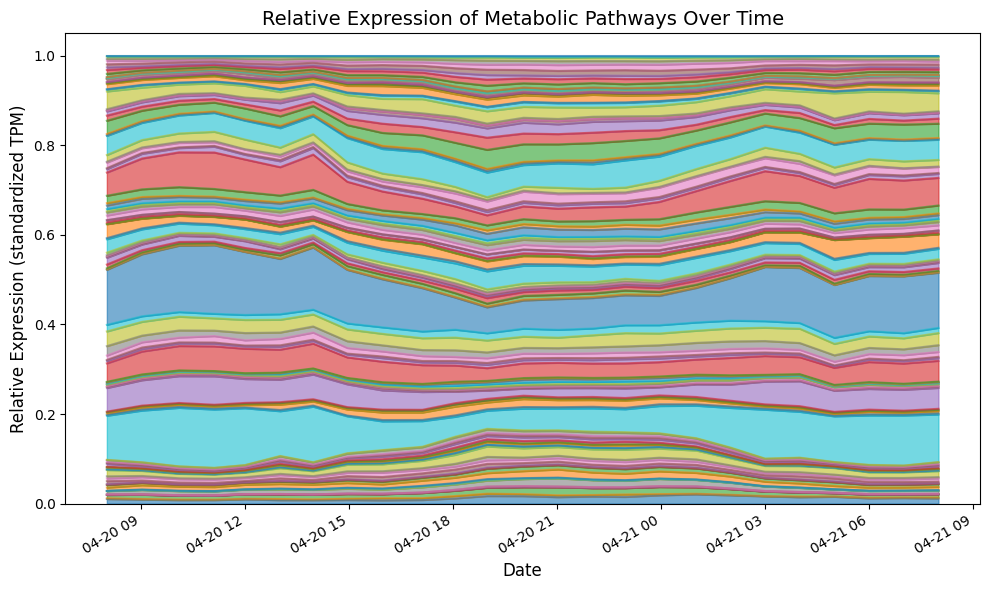

In [11]:
# Set up the figure
plt.figure(figsize=(10, 6))

# Convert the Date column to datetime format for proper plotting
data_KEGG['Date'] = pd.to_datetime(data_KEGG['Date'])

# Sort the dataframe by Date for better visualization
data_KEGG = data_KEGG.sort_values(by='Date')
# Replace 0 with NaN in the standardized TPL values to interrupt the line plot
data_KEGG.replace(0, np.nan, inplace=True)

# Set the Date as the x-axis and plot the relative expression of each module
data_KEGG.set_index('Date', inplace=True)

# Plot a stacked area chart for relative expression of each pathway over time
pathway_pivot = data_KEGG.pivot_table(index='Date', columns='KEGG_pathway', values='TPM', aggfunc='sum', fill_value=0)
pathway_pivot = pathway_pivot.div(pathway_pivot.sum(axis=1), axis=0)  # Standardize to relative expression
pathway_pivot.plot.area(ax=plt.gca(), alpha=0.6)

# Customize the plot for publication
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Expression (standardized TPM)', fontsize=12)
plt.title('Relative Expression of Metabolic Pathways Over Time', fontsize=14)
# Remove the legend 
plt.legend().set_visible(False)
plt.tight_layout()

# Save the plot as a publication-ready figure
#plt.savefig('pathway_module_expression_over_time.png', dpi=300)
plt.show()

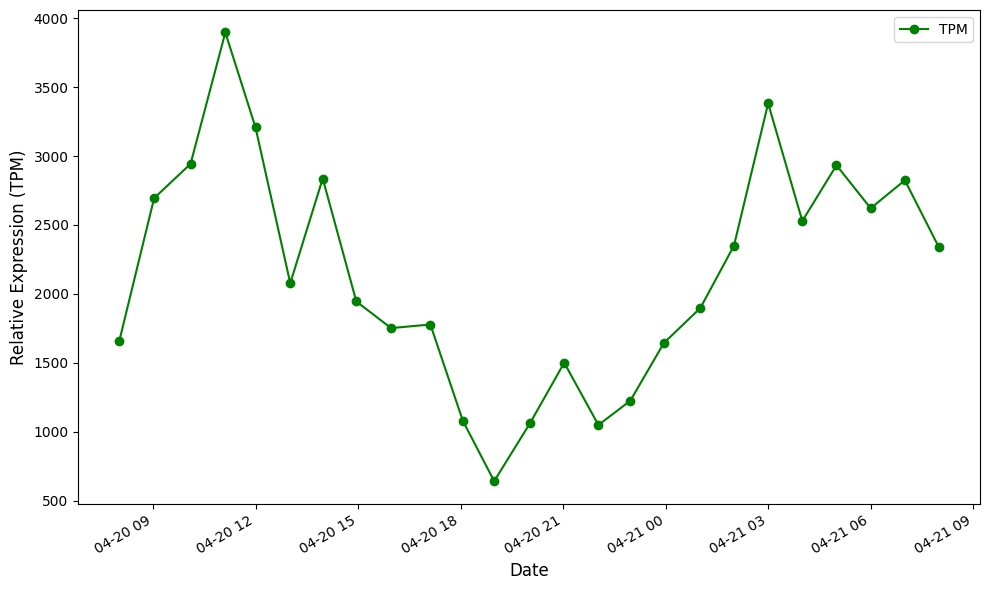

In [18]:
# Display the relative investment in photosynthesis-related pathways over time
pathway_photo = data_KEGG[data_KEGG['KEGG_pathway'].str.contains('Photosynthesis')]

# Sum the TPM values for photosynthesis-related pathways by date
photo_pivot = pathway_photo.pivot_table(index='Date', values='TPM', aggfunc='sum', fill_value=0)

# Save these sums for later analysis
photo_pivot.to_csv('../data/phaglo1_mapping/gene_expression/photosynthesis_pathway_TPM_expression_over_time.csv')

photo_pivot.plot(figsize=(10, 6), marker='o', color='green')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Expression (TPM)', fontsize=12)
plt.tight_layout()
#plt.savefig('photosynthesis_pathway_expression_over_time.png', dpi=300)
plt.show()

In [15]:
pathway_photo.head()

,gene_id,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-20 08:01:00,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832,-1.802973,0.543319,356.76
2023-04-20 08:01:00,gene_31347,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832,-1.802973,0.543319,356.76
2023-04-20 08:01:00,gene_31730,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR008333;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832,-1.802973,0.543319,356.76
2023-04-20 08:01:00,gene_23843,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832,-1.802973,0.543319,356.76
2023-04-20 09:02:00,gene_23843,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172,-1.069393,0.562920,231.00


## KOG Classes

Here, we'll try to create a clustered heatmap of higher-level GO terms.
First, we'll extract the GO terms from the data. For these, we'll get their ancestor terms (higher level grouping). 


In [94]:
data.head()

,gene_id,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
0,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.82,0.38,12.96,13.34,0.05,13.20,1286.832000,-1.802973,0.543319,356.76
1,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.71,0.34,14.91,15.25,0.06,13.29,1202.172000,-1.069393,0.562920,231.00
2,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.34,0.37,17.44,17.81,0.05,14.30,1326.340000,-0.290541,0.361021,224.76
3,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.02,0.35,15.94,16.29,0.05,13.36,1083.648000,1.187761,0.338537,235.20
4,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.40,0.30,17.13,17.43,0.05,12.82,1728.945333,2.587380,0.865567,411.48


In [95]:
# Explode the GO terms if they are comma-separated
data_KOG = data[data['KOG'].notna()].copy()
print(len(data_KOG))
data_KOG['KOG'] = data_KOG['KOG'].str.split(';')
print(len(data_KOG))
data_exploded = data_KOG.explode('KOG')
print(len(data_exploded))
unique_KOG_terms = data_exploded['KOG'].unique()
print(f"Unique KOG terms found: {len(unique_KOG_terms)}")

251650
251650
251650
Unique KOG terms found: 2992


In [96]:
data_exploded['KOG'].value_counts().head(10)

KOG
KOG4308    4275
KOG4177    3550
KOG0504    2450
KOG0027    2350
KOG0032    1975
KOG1021    1950
KOG0613    1575
KOG0048    1550
KOG3867    1525
KOG0619    1425
Name: count, dtype: int64

In [97]:
df = pd.read_csv("../data/phaglo1_mapping/annotation/kog_mapping.tsv", sep="\t", nrows=5)
print(df.head())
print(df.columns.tolist())

                                         Function ID  \
0                                                  A   
1                KOG2044 5'-3' exonuclease HKE1/RAT1   
2  KOG3387 60S ribosomal protein 15.5kD/SNU13, NH...   
3  KOG0105 Alternative splicing factor ASF/SF2 (R...   
4  KOG0107 Alternative splicing factor SRp20/9G8 ...   

              Function Description  \
0  RNA processing and modification   
1                                6   
2                                1   
3                                0   
4                                2   

   Gene Models in Phaeocystis globosa Pg-G v2.3  
0                                         507.0  
1                                           NaN  
2                                           NaN  
3                                           NaN  
4                                           NaN  
['Function ID', 'Function Description', 'Gene Models in Phaeocystis globosa Pg-G v2.3']


In [98]:
# Create a mapping of KOG IDs to their descriptions from the kog_mapping.tsv file
# This file was constructed by manually copying the KOG Classification table from the JGI KOG browser for Phaeocystis globosa Pg-G v2.3 https://mycocosm.jgi.doe.gov/cgi-bin/kogBrowser?expandclass=Z&type=KOG&db=Phaglo1

# Read the pasted TSV (3 columns: Function ID, Function Description, Gene Models)
df = pd.read_csv("../data/phaglo1_mapping/annotation/kog_mapping.tsv", sep="\t", header=0)


records = []
current_category = None
current_letter = None

for _, row in df.iterrows():
    fid = str(row.iloc[0]).strip()   # first column (Function ID or KOG ID)
    desc = str(row.iloc[1]).strip()  # second column (Function Description)

    # Detect category rows (A, B, C...) — skip the header itself
    if fid and len(fid) == 1 and desc != "Function Description":
        current_letter = fid
        current_category = desc
    elif fid.startswith("KOG"):
        # Split "KOGxxxx description"
        parts = fid.split(maxsplit=1)
        kog_id = parts[0]
        kog_desc = parts[1] if len(parts) > 1 else desc
        records.append({
            "KOG": kog_id,
            "KOG_desc": kog_desc,
            "KOG_class": current_letter,
            "KOG_category": current_category
        })

# Build mapping dataframe
kog_map = pd.DataFrame(records)
kog_map.to_csv("../data/phaglo1_mapping/annotation/kog_mapping_processed.tsv", sep="\t", index=False)

print(f"Saved {len(kog_map)} KOG entries with categories")

Saved 5384 KOG entries with categories


In [99]:
kog_map.head()

,KOG,KOG_desc,KOG_class,KOG_category
0,KOG2044,5'-3' exonuclease HKE1/RAT1,A,RNA processing and modification
1,KOG3387,"60S ribosomal protein 15.5kD/SNU13, NHP2/L7A f...",A,RNA processing and modification
2,KOG0105,Alternative splicing factor ASF/SF2 (RRM super...,A,RNA processing and modification
3,KOG0107,Alternative splicing factor SRp20/9G8 (RRM sup...,A,RNA processing and modification
4,KOG0106,Alternative splicing factor SRp55/B52/SRp75 (R...,A,RNA processing and modification


In [100]:
# Summarize expression by KOG_category
# First, merge KOG IDs with their descriptions and categories
data_exploded = data_exploded.merge(kog_map, on=['KOG', 'KOG_desc'], how='left')
grouped_expression = data_exploded.groupby(['KOG_category', 'sample'])['TPM'].sum().reset_index()

# Replace 0 with NaN to interrupt the heatmap
grouped_expression.replace(0, np.nan, inplace=True)

# Merge KOG expression with env_data to include the Date column
grouped_expression_with_date = grouped_expression.reset_index().merge(env_data[['sample', 'Date']], on='sample', how='left')

# Convert the Date column to datetime format for proper plotting
grouped_expression_with_date['Date'] = pd.to_datetime(grouped_expression_with_date['Date'])

# Sort the dataframe by Date for better visualization
grouped_expression_with_date = grouped_expression_with_date.sort_values(by='Date')

# Add hours since start for regression analysis downstream
grouped_expression_with_date['hours_since_start'] = (grouped_expression_with_date['Date'] - grouped_expression_with_date['Date'].min()).dt.total_seconds() / 3600

# Pivot the data for heatmap plotting
pivoted_expression = grouped_expression_with_date.pivot(index='KOG_category', columns='Date', values='TPM')

In [101]:
level = 'KOG_category'

In [102]:
# Check unique KOG_categories
print(f"Unique KOG_categories found: {len(data_exploded[level].unique())}")
print(f"pivoted_expression shape: {pivoted_expression.shape}")

Unique KOG_categories found: 26
pivoted_expression shape: (25, 25)


In [103]:
pivoted_expression.sum(axis=1).sort_values(ascending=False).index[:50]

Index(['Translation, ribosomal structure and biogenesis',
       'Posttranslational modification, protein turnover, chaperones',
       'Carbohydrate transport and metabolism',
       'General function prediction only', 'Energy production and conversion',
       'Signal transduction mechanisms',
       'Intracellular trafficking, secretion, and vesicular transport',
       'Cytoskeleton', 'RNA processing and modification', 'Function unknown',
       'Amino acid transport and metabolism', 'Transcription',
       'Cell cycle control, cell division, chromosome partitioning',
       'Lipid transport and metabolism', 'Coenzyme transport and metabolism',
       'Secondary metabolites biosynthesis, transport and catabolism',
       'Inorganic ion transport and metabolism',
       'Chromatin structure and dynamics',
       'Replication, recombination and repair',
       'Cell wall/membrane/envelope biogenesis',
       'Nucleotide transport and metabolism', 'Defense mechanisms',
       'Extrace

In [104]:
# Remove the unknown category for better visualization
categories_to_remove = ['Function unknown']
pivoted_expression = pivoted_expression[~pivoted_expression.index.isin(categories_to_remove)]

In [105]:
# Calculate mean expression for each KOG_category
mean_expression = pivoted_expression.mean(axis=1)

# Z-score normalize the expression data
zscore = lambda x: (x - x.mean()) / x.std()
pivoted_expression_zscore = pivoted_expression.apply(zscore, axis=1)

In [106]:
pivoted_expression.head()

Date,2023-04-20 08:01:00,2023-04-20 09:02:00,2023-04-20 10:06:00,2023-04-20 11:07:00,2023-04-20 12:00:00,2023-04-20 13:01:00,2023-04-20 13:58:00,2023-04-20 14:57:00,2023-04-20 15:58:00,2023-04-20 17:07:00,...,2023-04-20 22:58:00,2023-04-20 23:57:00,2023-04-21 01:01:00,2023-04-21 02:00:00,2023-04-21 03:00:00,2023-04-21 04:00:00,2023-04-21 05:00:00,2023-04-21 06:00:00,2023-04-21 07:00:00,2023-04-21 08:00:00
KOG_category,,,,,,,,,,,,,,,,,,,,,
Amino acid transport and metabolism,9427.256315,13972.207312,12497.745829,16098.638400,12652.934295,13563.801673,15844.730733,11605.582070,14098.623514,14779.317657,...,15140.688055,14985.330447,14496.574707,15261.110972,15737.166621,13493.218706,17878.134838,16541.641520,16683.074951,13346.904355
Carbohydrate transport and metabolism,27790.556041,44487.590147,43813.958383,53414.869571,39520.206405,33401.500824,42810.301885,29659.286397,32811.742739,30113.182652,...,23589.658148,23963.460516,26242.560331,33336.173983,43530.369729,40728.844920,45484.124023,45066.105499,46189.947146,39027.570404
"Cell cycle control, cell division, chromosome partitioning",9608.032470,8196.851006,8316.370966,7961.645758,7041.797562,8682.242100,7452.136323,9373.422663,12286.728511,10309.631344,...,14747.581607,14102.958632,8743.592345,7801.687379,5492.700207,7870.957273,5656.937435,7179.701028,6948.125208,9431.399142
Cell motility,795.174845,641.196949,669.042910,415.103550,371.361903,425.432888,350.215315,486.850987,430.532194,368.913316,...,481.502830,659.659411,420.386483,433.283063,316.255845,428.854372,267.242810,408.086238,395.342711,562.198161
Cell wall/membrane/envelope biogenesis,2833.933612,3499.393984,3039.384458,3160.034223,2293.388931,3103.392494,2934.822872,2612.149326,4162.097701,4144.711385,...,4874.606813,4842.711186,4071.247539,4218.479664,3829.056271,4043.326286,4166.820129,4204.715224,3835.574624,3822.771977


/var/folders/sw/y59p6zb57zd9ntdpcr65r3q40000gn/T/ipykernel_77295/4030697323.py:75: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


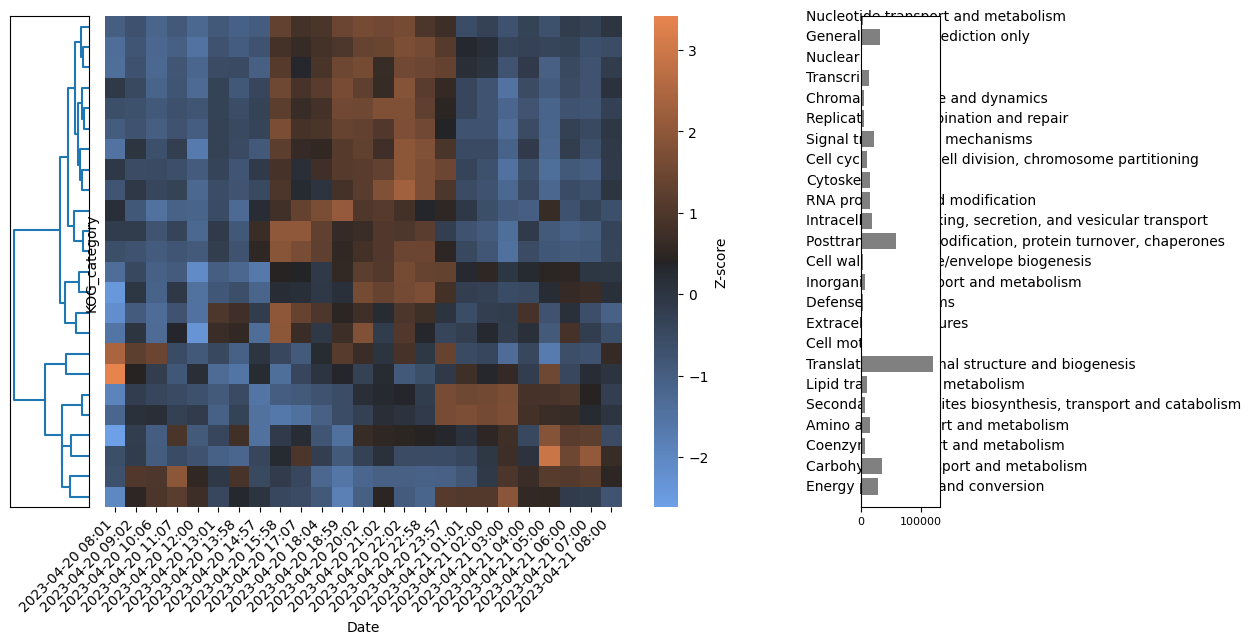

In [107]:
# Perform hierarchical clustering on the Z-score normalized data
row_linkage = linkage(pivoted_expression_zscore.fillna(0), method='ward')

# Get the ordered row indices from the dendrogram
row_order = leaves_list(row_linkage)

# Reorder the rows in the heatmap and mean expression based on the clustering
pivoted_expression_zscore = pivoted_expression_zscore.iloc[row_order]
mean_expression = mean_expression.iloc[row_order]

# Set up the figure with additional space for GO labels
fig = plt.figure(figsize=(12, 8))
dendro_ax = plt.subplot2grid((10, 10), (2, 0), colspan=1, rowspan=8)  # Dendrogram on the left
heatmap_ax = plt.subplot2grid((10, 10), (2, 1), colspan=7, rowspan=8)  # Heatmap
labels_ax = plt.subplot2grid((10, 10), (2, 8), colspan=1, rowspan=8, sharey=heatmap_ax)  # GO labels
side_ax = plt.subplot2grid((10, 10), (2, 9), colspan=1, rowspan=8, sharey=heatmap_ax)  # Sidebar

# Plot the dendrogram
dendrogram(
    row_linkage, 
    ax=dendro_ax, 
    orientation='left', 
    labels=pivoted_expression_zscore.index,
    color_threshold=0
)
dendro_ax.invert_yaxis()  # Align the dendrogram order with the heatmap
dendro_ax.set_xticks([])  # Hide x-ticks
dendro_ax.set_yticks([])  # Hide y-ticks

cmap = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)

# Plot the heatmap
sns.heatmap(
    pivoted_expression_zscore,
    cmap=cmap,
    ax=heatmap_ax,
    cbar_kws={'label': 'Z-score'}
)

# Plot the GO labels
labels_ax.set_xlim(0, 1)  # Arbitrary x-range for text alignment
labels_ax.set_xticks([])  # Remove x-ticks
labels_ax.set_yticks([])  # Remove y-ticks
for i, label in enumerate(pivoted_expression_zscore.index):
    labels_ax.text(0.5, i, label, ha='left', va='center', fontsize=10)
labels_ax.set_axis_off()  # Hide the axis for cleaner appearance

# Plot the sidebar for mean expression
yticks = range(len(mean_expression))  # Align y-ticks with the number of rows

side_ax.barh(
    yticks,
    mean_expression,
    color='gray',
    align='center'
)

# Adjust x-axis for the sidebar
side_ax.set_xlim([0, mean_expression.max() * 1.1])
side_ax.set_xlabel(None)
side_ax.xaxis.set_label_position('top')  # Place label on top
side_ax.tick_params(axis='x', labelsize=8)

# Remove the y-axis for the sidebar to avoid duplicate labels
side_ax.yaxis.set_visible(False)

# Format the x-axis ticks to show the date and hour
heatmap_ax.set_xticklabels(
    pivoted_expression.columns.strftime('%Y-%m-%d %H:%M'),
    rotation=45,
    ha='right'
)

# Final adjustments
plt.tight_layout()
# Save the figure as a SVG file
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_category_heatmap.svg')

plt.show()

In [52]:
# Per KOG category, print the most highly expressed KOGs
for category in data_exploded['KOG_category'].unique():
    subset = data_exploded[data_exploded['KOG_category'] == category]
    kog_expression = subset.groupby('KOG')['TPM'].sum().sort_values(ascending=False)
    top_kogs = kog_expression.head(5)
    print(f"Category: {category}")
    for kog_id, expr in top_kogs.items():
        kog_desc = subset[subset['KOG'] == kog_id]['KOG_desc'].iloc[0]
        print(f"  KOG ID: {kog_id}, Description: {kog_desc}, Total TPM: {expr}")
    print("\n")

Category: Energy production and conversion
  KOG ID: KOG1748, Description: Acyl carrier protein/NADH-ubiquinone oxidoreductase, NDUFAB1/SDAP subunit, Total TPM: 85955.648377
  KOG ID: KOG1158, Description: NADP/FAD dependent oxidoreductase, Total TPM: 54387.435366
  KOG ID: KOG1531, Description: F0F1-type ATP synthase, gamma subunit, Total TPM: 48201.733448
  KOG ID: KOG1671, Description: Ubiquinol cytochrome c reductase, subunit RIP1, Total TPM: 43027.366567
  KOG ID: KOG0232, Description: Vacuolar H+-ATPase V0 sector, subunits c/c', Total TPM: 20033.5075


Category: Lipid transport and metabolism
  KOG ID: KOG1748, Description: Acyl carrier protein/NADH-ubiquinone oxidoreductase, NDUFAB1/SDAP subunit, Total TPM: 85955.648377
  KOG ID: KOG4569, Description: Predicted lipase, Total TPM: 10885.496794
  KOG ID: KOG1269, Description: SAM-dependent methyltransferases, Total TPM: 8136.413974
  KOG ID: KOG4232, Description: Delta 6-fatty acid desaturase/delta-8 sphingolipid desaturase, Total

In [55]:
# As above, but save full lists of KOGs per category with their total expression
kog_summary_records = []
for category in data_exploded['KOG_category'].unique():
    subset = data_exploded[data_exploded['KOG_category'] == category]
    kog_expression = subset.groupby('KOG')['TPM'].sum().sort_values(ascending=False)
    for kog_id, expr in kog_expression.items():
        kog_desc = subset[subset['KOG'] == kog_id]['KOG_desc'].iloc[0]
        kog_summary_records.append({
            'KOG_category': category,
            'KOG_ID': kog_id,
            'KOG_desc': kog_desc,
            'Total_TPM': expr
        })
kog_summary_df = pd.DataFrame(kog_summary_records)
# Sort by category and total TPM
kog_summary_df = kog_summary_df.sort_values(by=['KOG_category', 'Total_TPM'], ascending=[True, False])
# Save to CSV
kog_summary_df.to_csv('../data/analysis/phaeocystis_kog_expression_summary.csv', index=False)

In [60]:
# Same but for KEGG_def per KEG pathway
data_KEGG = data[data['KEGG_def'].notna()].copy()
data_KEGG['KEGG_def'] = data_KEGG['KEGG_def'].str.split(';')
data_KEGG = data_KEGG.explode('KEGG_def')

KEGG_summary_records = []
for pathway in data_KEGG['KEGG_pathway'].unique():
    pathway_data = data_KEGG[data_KEGG['KEGG_pathway'] == pathway]
    KEGG_expression = pathway_data.groupby('KEGG_def')['TPM'].sum().sort_values(ascending=False)
    for kegg_def, total_tpm in KEGG_expression.items():
        KEGG_summary_records.append({'KEGG_pathway': pathway, 'KEGG_def': kegg_def, 'Total_TPM': total_tpm})

KEGG_summary = pd.DataFrame(KEGG_summary_records)
KEGG_summary = KEGG_summary.sort_values(by='Total_TPM', ascending=False)
KEGG_summary.to_csv('../data/analysis/phaeocystis_kegg_pathway_expression_summary.csv', index=False)

### Correlation of KOG expression

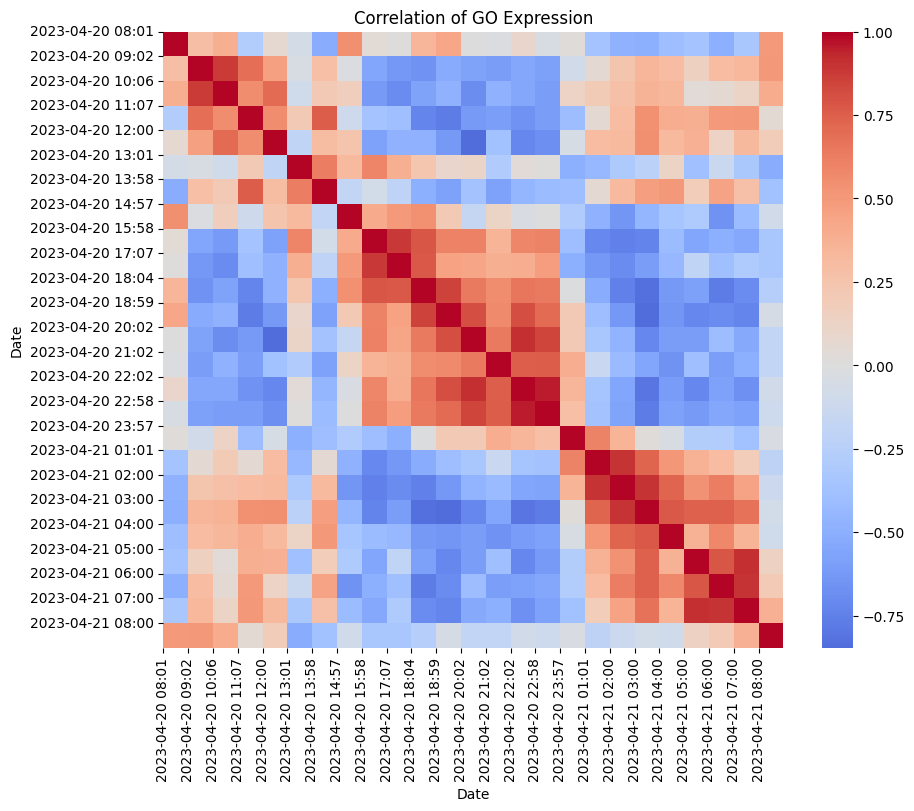

In [25]:
# Plot the correlation of the samples based on the GO slim categories
plt.figure(figsize=(10, 8))
sns.heatmap(pivoted_expression_zscore.corr(), cmap='coolwarm', center=0)
plt.title('Correlation of GO Expression')
# Format the x-axis ticks to show the date and hour
plt.xticks(ticks=range(len(grouped_expression_with_date['Date'].unique())), labels=grouped_expression_with_date['Date'].unique().strftime('%Y-%m-%d %H:%M'))
plt.yticks(ticks=range(len(grouped_expression_with_date['Date'].unique())), labels=grouped_expression_with_date['Date'].unique().strftime('%Y-%m-%d %H:%M'))

# Save the figure as a SVG file
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_samples.svg', format='svg', bbox_inches='tight', dpi=800)
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_samples.png', format='png', bbox_inches='tight', dpi=800)
plt.show()

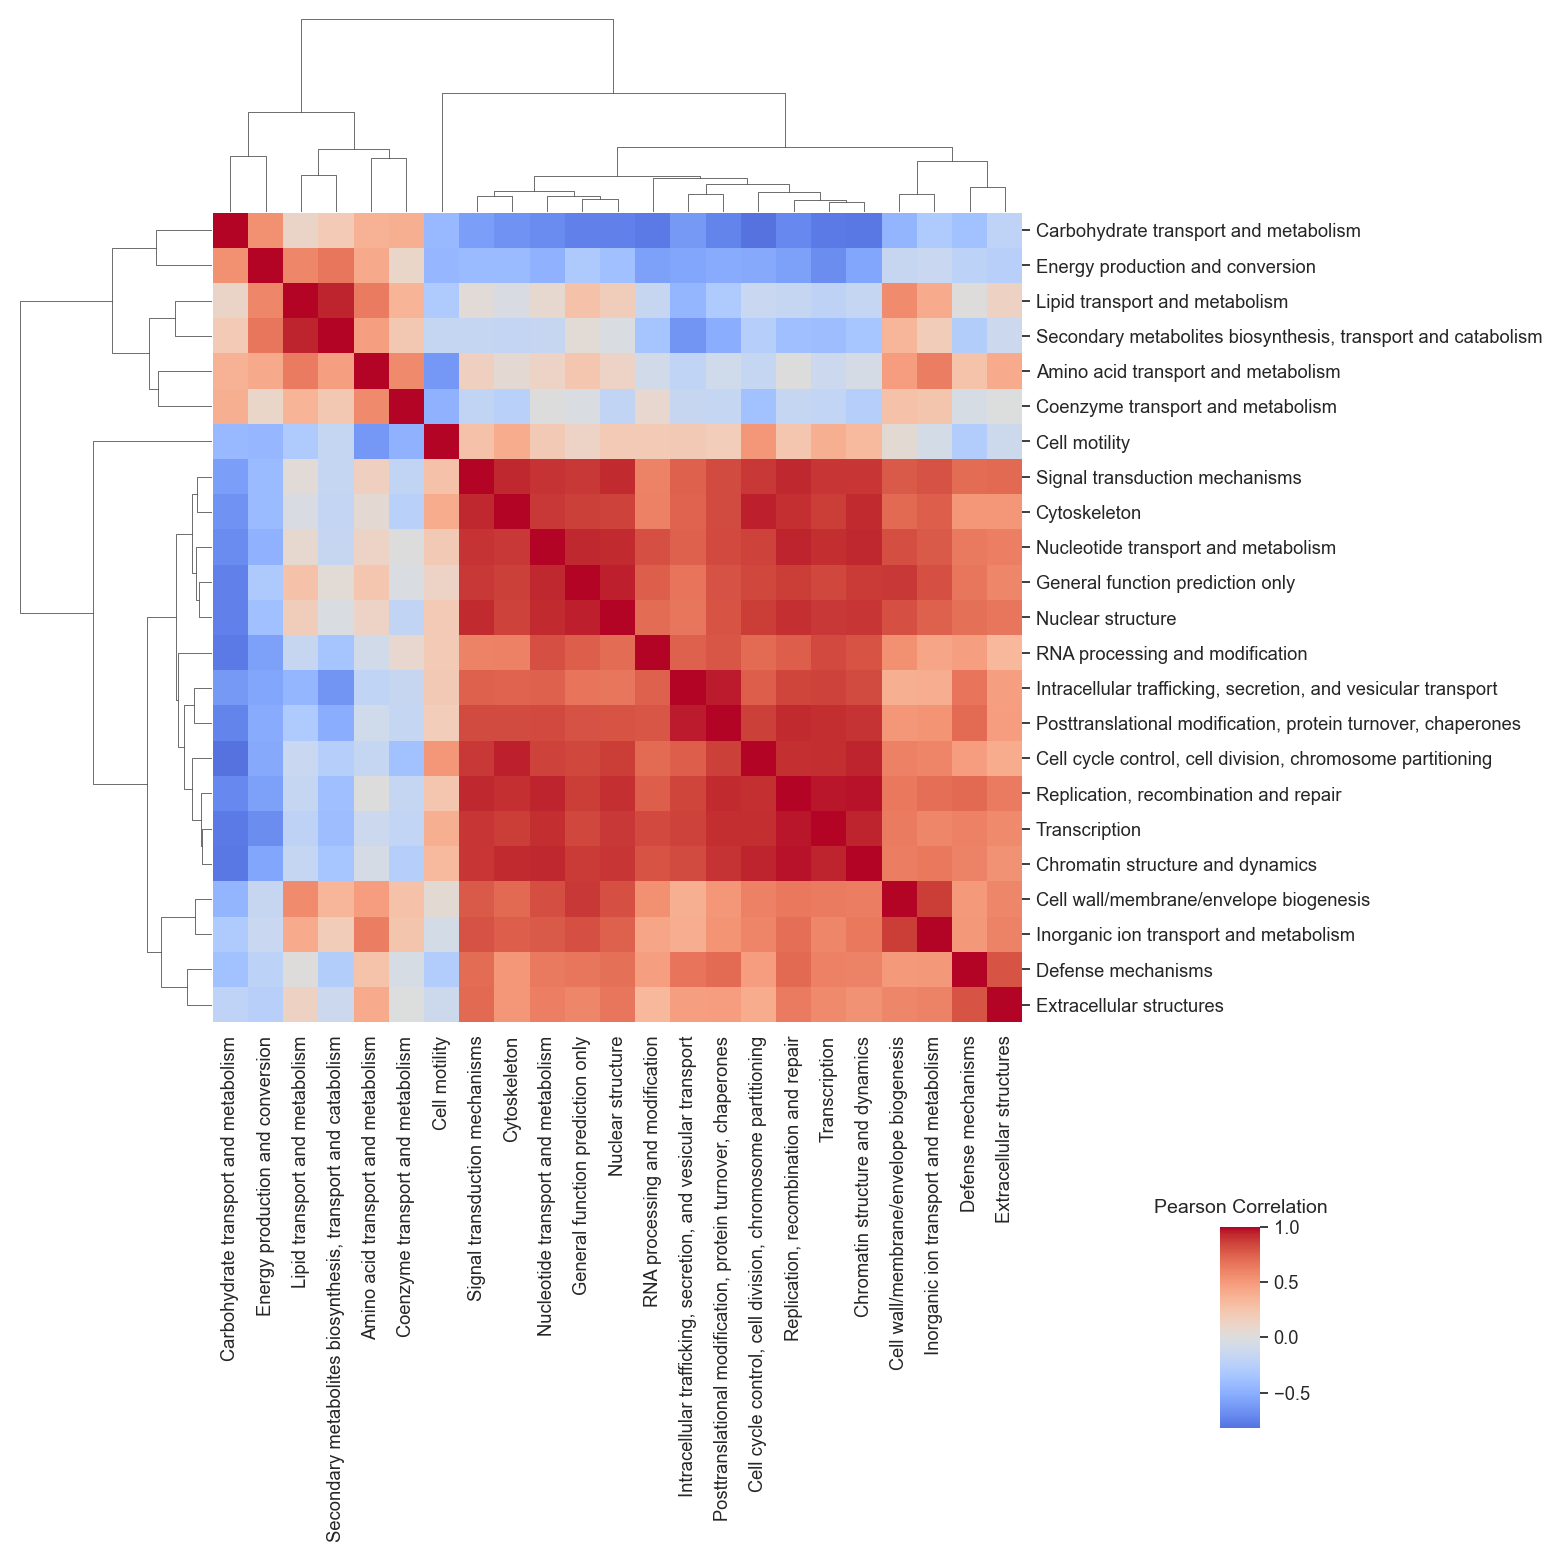

In [26]:
# Plot the correlation between expression of GO slim categories
sns.set(font_scale=1.2)

# Compute the correlation matrix
correlation_matrix = pivoted_expression_zscore.T.corr()

# Create the clustermap
kws = dict(figsize=(16, 16))
g = sns.clustermap(correlation_matrix, cmap='coolwarm', center=0, **kws)

# Adjust the colorbar position
x0, y0, width, height = g.cbar_pos
g.ax_cbar.set_position([x0 + 0.75, y0 - 0.7, width * 0.5, height * 0.7])  # Adjust to lower right
g.ax_cbar.set_title('Pearson Correlation', fontsize=14, pad=10)  # Adjust title padding with `pad`
g.ax_cbar.tick_params(axis='x', length=5)  # Adjust tick length
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# Save the figure as a SVG file
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_categories.svg', format='svg', bbox_inches='tight', dpi=800)
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_categories.png', format='png', bbox_inches='tight', dpi=800)
plt.show()

## Station 51
Repeat the analysis for station 51.

In [39]:
# Read Phaglo1 gene expression data
expression = pd.read_csv("../data/phaglo1_mapping/gene_expression/gene_tpm.tsv", sep="\t")
# Reshape to long format
expression = expression.melt(id_vars=["gene_id"], var_name="sample", value_name="TPM")
# Only retain samples from station 51
expression = expression[expression['sample'].str.contains('51_')]
# Remove outlier sample 51_17
expression = expression[expression['sample'] != '51_17']

expression.head()

,gene_id,sample,TPM
0,gene_1,51_1,0.000000
1,gene_10,51_1,20.486173
2,gene_100,51_1,0.000000
3,gene_1000,51_1,42.235906
4,gene_10000,51_1,34.065645


In [40]:
# Create a dataframe containing the sample names, functional annotation categories of interest and TPL
functional_columns = ['gene_id', 'KEGG_def', 'KEGG_pathway', 'GO', 'GO_name', 'GO_type', 'IPR', 'KOG', 'KOG_desc', 'CAZy', 'CAZy_desc', 'signalp']
data = functional_annotation[functional_columns].merge(expression, on='gene_id', how='inner')
data = data.merge(env_data, on='sample', how='inner')

data.head()

,gene_id,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
0,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.08,0.16,6.96,7.12,0.10,7.24,65.846667,1.817039,0.737313,61.692
1,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.45,0.15,6.19,6.34,0.14,7.06,167.438667,2.129479,0.933577,0.000
2,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.53,0.15,6.13,6.28,0.12,7.13,210.709333,1.852063,0.844862,49.752
3,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,255.861333,1.210772,0.645538,58.860
4,gene_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.18,0.15,6.54,6.69,0.15,7.53,223.878667,0.336479,0.489504,41.664


In [41]:
# Remove the 'ko:' prefix and split multiple KOs
data_KEGG = data[data['KEGG_pathway'].notna()].copy()
data_KEGG['KEGG_pathway'] = data_KEGG['KEGG_pathway'].str.split(';')

# Explode the dataframe to have one KO per row (duplicating TPL values accordingly)
data_KEGG = data_KEGG.explode('KEGG_pathway')

# Inspect the data
data_KEGG.head()

,gene_id,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,...,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity,PP
140,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,3.08,0.16,6.96,7.12,0.10,7.24,65.846667,1.817039,0.737313,61.692
140,gene_10003,Ferredoxin--NADP(+) reductase.,Porphyrin and chlorophyll metabolism,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,3.08,0.16,6.96,7.12,0.10,7.24,65.846667,1.817039,0.737313,61.692
141,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,3.45,0.15,6.19,6.34,0.14,7.06,167.438667,2.129479,0.933577,0.000
141,gene_10003,Ferredoxin--NADP(+) reductase.,Porphyrin and chlorophyll metabolism,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,3.45,0.15,6.19,6.34,0.14,7.06,167.438667,2.129479,0.933577,0.000
142,gene_10003,Ferredoxin--NADP(+) reductase.,Photosynthesis,GO:0004324;GO:0006118;GO:0015039;GO:0016491,NADPH-adrenodoxin reductase activity;electron ...,biological_process;molecular_function,IPR001433;IPR015701;IPR017927;IPR017938,KOG1158,NADP/FAD dependent oxidoreductase,NaN,...,3.53,0.15,6.13,6.28,0.12,7.13,210.709333,1.852063,0.844862,49.752


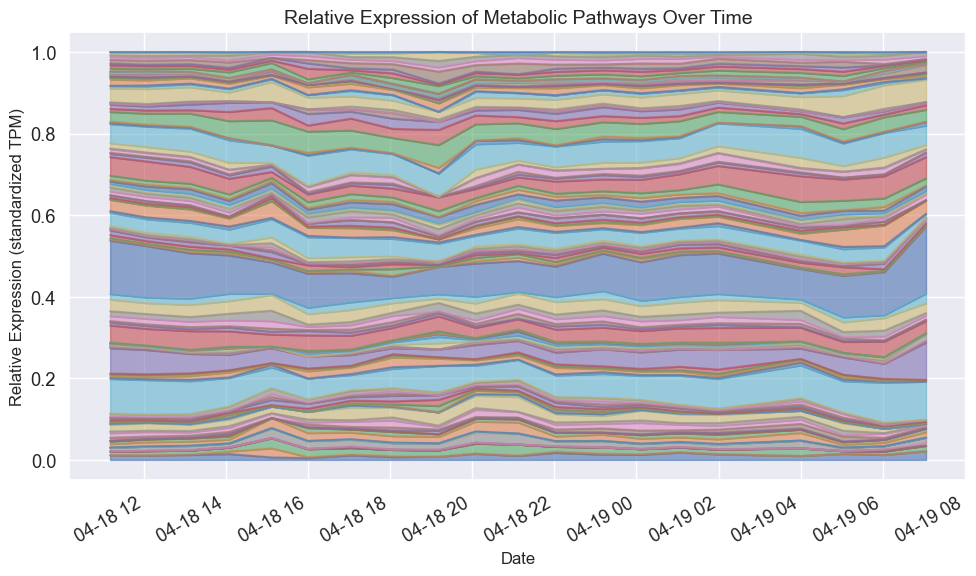

In [42]:
# Set up the figure
plt.figure(figsize=(10, 6))

# Convert the Date column to datetime format for proper plotting
data_KEGG['Date'] = pd.to_datetime(data_KEGG['Date'])

# Sort the dataframe by Date for better visualization
data_KEGG = data_KEGG.sort_values(by='Date')
# Replace 0 with NaN in the standardized TPL values to interrupt the line plot
data_KEGG.replace(0, np.nan, inplace=True)

# Set the Date as the x-axis and plot the relative expression of each module
data_KEGG.set_index('Date', inplace=True)

# Plot a stacked area chart for relative expression of each pathway over time
pathway_pivot = data_KEGG.pivot_table(index='Date', columns='KEGG_pathway', values='TPM', aggfunc='sum', fill_value=0)
pathway_pivot = pathway_pivot.div(pathway_pivot.sum(axis=1), axis=0)  # Standardize to relative expression
pathway_pivot.plot.area(ax=plt.gca(), alpha=0.6)

# Customize the plot for publication
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Expression (standardized TPM)', fontsize=12)
plt.title('Relative Expression of Metabolic Pathways Over Time', fontsize=14)
# Remove the legend 
plt.legend().set_visible(False)
plt.tight_layout()

# Save the plot as a publication-ready figure
#plt.savefig('pathway_module_expression_over_time.png', dpi=300)
plt.show()

In [43]:
# Explode the GO terms if they are comma-separated
data_KOG = data[data['KOG'].notna()].copy()
print(len(data_KOG))
data_KOG['KOG'] = data_KOG['KOG'].str.split(';')
print(len(data_KOG))
data_exploded = data_KOG.explode('KOG')
print(len(data_exploded))
unique_KOG_terms = data_exploded['KOG'].unique()
print(f"Unique KOG terms found: {len(unique_KOG_terms)}")

201320
201320
201320
Unique KOG terms found: 2992


In [44]:
data_exploded['KOG'].value_counts().head(10)

KOG
KOG4308    3420
KOG4177    2840
KOG0504    1960
KOG0027    1880
KOG0032    1580
KOG1021    1560
KOG0613    1260
KOG0048    1240
KOG3867    1220
KOG0619    1140
Name: count, dtype: int64

In [46]:
# Summarize expression by KOG_category
# First, merge KOG IDs with their descriptions and categories
data_exploded = data_exploded.merge(kog_map, on='KOG', how='left')
grouped_expression = data_exploded.groupby(['KOG_category', 'sample'])['TPM'].sum().reset_index()

# Replace 0 with NaN to interrupt the heatmap
grouped_expression.replace(0, np.nan, inplace=True)

# Merge KOG expression with env_data to include the Date column
grouped_expression_with_date = grouped_expression.reset_index().merge(env_data[['sample', 'Date']], on='sample', how='left')

# Convert the Date column to datetime format for proper plotting
grouped_expression_with_date['Date'] = pd.to_datetime(grouped_expression_with_date['Date'])

# Sort the dataframe by Date for better visualization
grouped_expression_with_date = grouped_expression_with_date.sort_values(by='Date')

# Add hours since start for regression analysis downstream
grouped_expression_with_date['hours_since_start'] = (grouped_expression_with_date['Date'] - grouped_expression_with_date['Date'].min()).dt.total_seconds() / 3600

# Pivot the data for heatmap plotting
pivoted_expression = grouped_expression_with_date.pivot(index='KOG_category', columns='Date', values='TPM')

In [47]:
pivoted_expression.sum(axis=1).sort_values(ascending=False).index[:50]

Index(['Translation, ribosomal structure and biogenesis', 'Cytoskeleton',
       'Posttranslational modification, protein turnover, chaperones',
       'General function prediction only',
       'Carbohydrate transport and metabolism',
       'Signal transduction mechanisms', 'Energy production and conversion',
       'Intracellular trafficking, secretion, and vesicular transport',
       'Function unknown', 'RNA processing and modification',
       'Amino acid transport and metabolism', 'Transcription',
       'Cell cycle control, cell division, chromosome partitioning',
       'Lipid transport and metabolism',
       'Inorganic ion transport and metabolism',
       'Chromatin structure and dynamics', 'Coenzyme transport and metabolism',
       'Cell wall/membrane/envelope biogenesis',
       'Replication, recombination and repair',
       'Secondary metabolites biosynthesis, transport and catabolism',
       'Nucleotide transport and metabolism', 'Extracellular structures',
       'D

In [48]:
# Remove the translation, ribosomal and unknown categories for better visualization
categories_to_remove = ['Translation, ribosomal structure and biogenesis', 'Function unknown']
pivoted_expression = pivoted_expression[~pivoted_expression.index.isin(categories_to_remove)]

In [49]:
# Calculate mean expression for each KOG_category
mean_expression = pivoted_expression.mean(axis=1)

# Z-score normalize the expression data
zscore = lambda x: (x - x.mean()) / x.std()
pivoted_expression_zscore = pivoted_expression.apply(zscore, axis=1)

In [50]:
pivoted_expression.head()

Date,2023-04-18 11:11:00,2023-04-18 12:05:00,2023-04-18 13:08:00,2023-04-18 14:05:00,2023-04-18 15:07:00,2023-04-18 16:00:00,2023-04-18 17:03:00,2023-04-18 18:04:00,2023-04-18 19:11:00,2023-04-18 20:05:00,2023-04-18 21:07:00,2023-04-18 22:02:00,2023-04-18 23:11:00,2023-04-19 00:07:00,2023-04-19 01:03:00,2023-04-19 01:59:00,2023-04-19 04:00:00,2023-04-19 05:02:00,2023-04-19 06:02:00,2023-04-19 07:03:00
KOG_category,,,,,,,,,,,,,,,,,,,,
Amino acid transport and metabolism,14116.013971,16063.769959,15893.226367,13807.100449,13903.305007,13580.620240,16767.950147,13823.298334,6786.020365,13954.409430,16765.435610,14944.438918,17115.073536,16909.961480,18088.680059,19512.156641,15110.132431,18329.992600,16756.900475,18171.169064
Carbohydrate transport and metabolism,41125.767882,43265.035436,38945.617869,30449.850794,24750.152118,25967.367517,22392.373697,21725.798893,19466.019677,24361.803865,28420.353297,27784.934290,30407.923002,30420.453800,33519.634620,36059.767651,35481.193627,39080.353138,42509.018958,51074.228216
"Cell cycle control, cell division, chromosome partitioning",11621.127531,10088.940534,11265.592946,11150.354609,15907.990379,12201.639282,12951.232933,15348.905565,12410.524612,19343.517358,20516.371853,16832.152235,13981.404391,16410.571090,14087.272079,10679.891634,5724.033658,7185.348951,7514.395704,4469.936328
Cell motility,1286.730451,711.408132,787.993946,1475.732363,NaN,1554.106113,1157.677775,1027.631997,2052.342647,3261.546459,2531.582899,1629.359904,1818.092791,1226.373415,2289.410026,943.313765,1293.034992,1084.623735,322.155048,NaN
Cell wall/membrane/envelope biogenesis,4214.957754,4230.533627,3814.395956,3439.551483,5724.833828,4147.275971,4116.869077,5911.127665,2908.924945,3481.131139,4991.432959,4422.191191,4123.291971,4936.797798,4345.210179,3786.577671,4676.325602,6867.088692,5989.679775,1849.386695


/var/folders/sw/y59p6zb57zd9ntdpcr65r3q40000gn/T/ipykernel_39406/3078345125.py:75: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


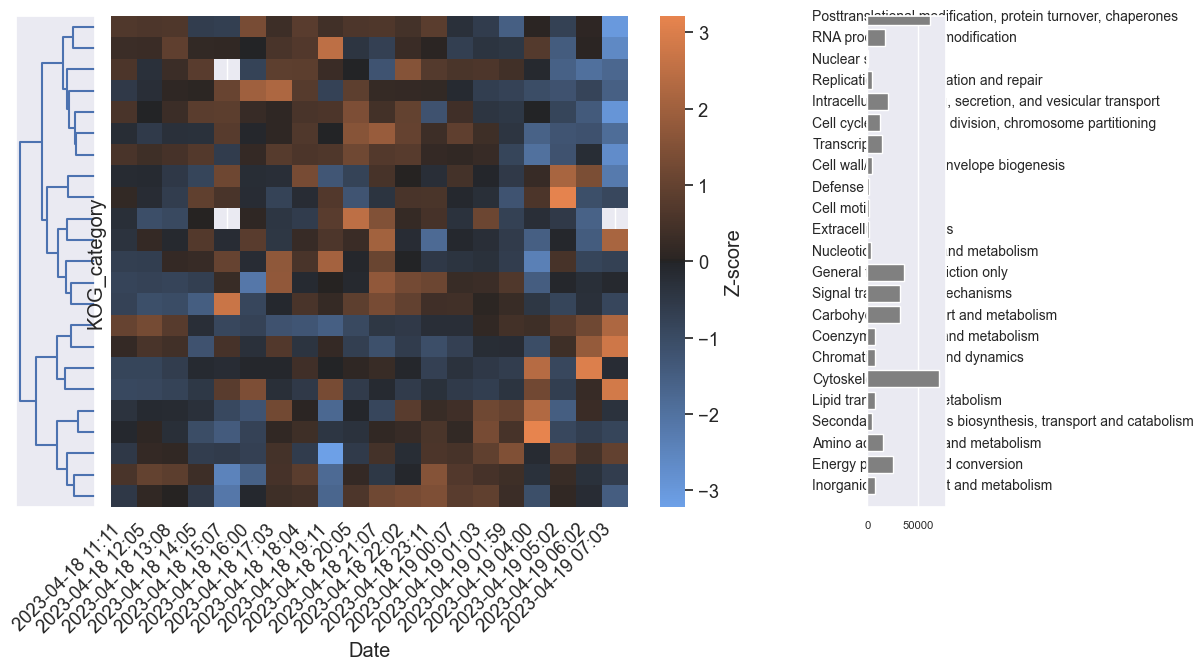

In [ ]:
# Perform hierarchical clustering on the Z-score normalized data
row_linkage = linkage(pivoted_expression_zscore.fillna(0), method='ward')

# Get the ordered row indices from the dendrogram
row_order = leaves_list(row_linkage)

# Reorder the rows in the heatmap and mean expression based on the clustering
pivoted_expression_zscore = pivoted_expression_zscore.iloc[row_order]
mean_expression = mean_expression.iloc[row_order]

# Set up the figure with additional space for GO labels
fig = plt.figure(figsize=(12, 8))
dendro_ax = plt.subplot2grid((10, 10), (2, 0), colspan=1, rowspan=8)  # Dendrogram on the left
heatmap_ax = plt.subplot2grid((10, 10), (2, 1), colspan=7, rowspan=8)  # Heatmap
labels_ax = plt.subplot2grid((10, 10), (2, 8), colspan=1, rowspan=8, sharey=heatmap_ax)  # GO labels
side_ax = plt.subplot2grid((10, 10), (2, 9), colspan=1, rowspan=8, sharey=heatmap_ax)  # Sidebar

# Plot the dendrogram
dendrogram(
    row_linkage, 
    ax=dendro_ax, 
    orientation='left', 
    labels=pivoted_expression_zscore.index,
    color_threshold=0
)
dendro_ax.invert_yaxis()  # Align the dendrogram order with the heatmap
dendro_ax.set_xticks([])  # Hide x-ticks
dendro_ax.set_yticks([])  # Hide y-ticks

cmap = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)

# Plot the heatmap
sns.heatmap(
    pivoted_expression_zscore,
    cmap=cmap,
    ax=heatmap_ax,
    cbar_kws={'label': 'Z-score'}
)

# Plot the GO labels
labels_ax.set_xlim(0, 1)  # Arbitrary x-range for text alignment
labels_ax.set_xticks([])  # Remove x-ticks
labels_ax.set_yticks([])  # Remove y-ticks
for i, label in enumerate(pivoted_expression_zscore.index):
    labels_ax.text(0.5, i, label, ha='left', va='center', fontsize=10)
labels_ax.set_axis_off()  # Hide the axis for cleaner appearance

# Plot the sidebar for mean expression
yticks = range(len(mean_expression))  # Align y-ticks with the number of rows

side_ax.barh(
    yticks,
    mean_expression,
    color='gray',
    align='center'
)

# Adjust x-axis for the sidebar
side_ax.set_xlim([0, mean_expression.max() * 1.1])
side_ax.set_xlabel(None)
side_ax.xaxis.set_label_position('top')  # Place label on top
side_ax.tick_params(axis='x', labelsize=8)

# Remove the y-axis for the sidebar to avoid duplicate labels
side_ax.yaxis.set_visible(False)

# Format the x-axis ticks to show the date and hour
heatmap_ax.set_xticklabels(
    pivoted_expression.columns.strftime('%Y-%m-%d %H:%M'),
    rotation=45,
    ha='right'
)

# Final adjustments
plt.tight_layout()
# Save the figure as a SVG file
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_category_heatmap_51.svg')

plt.show()

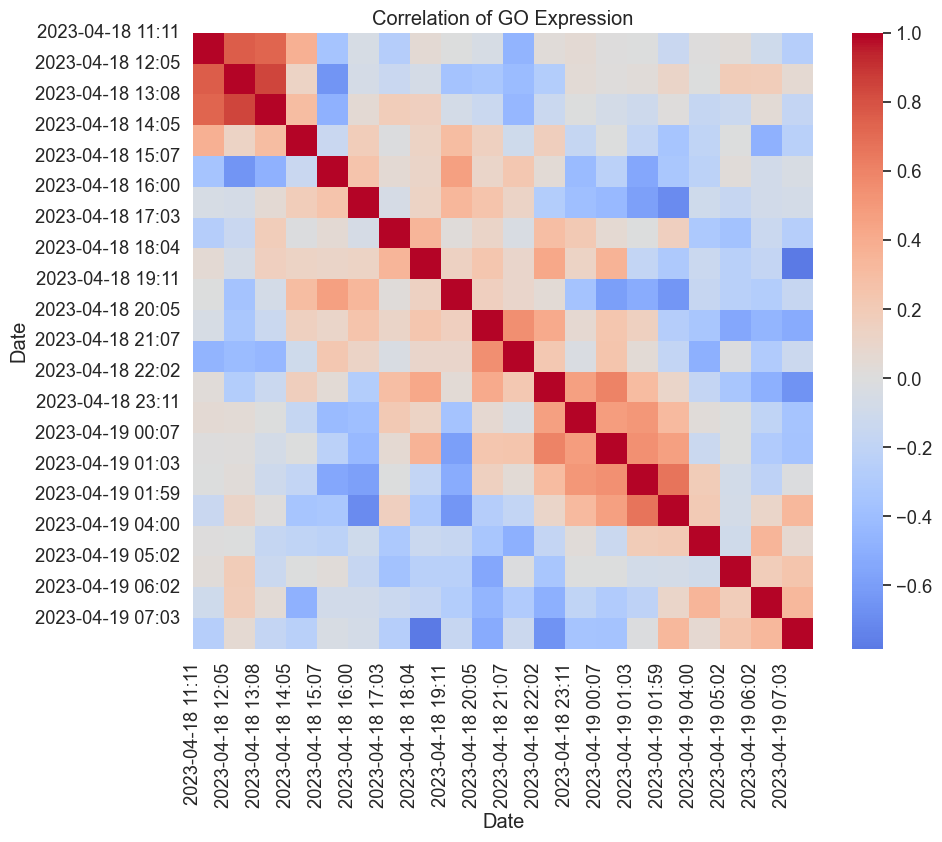

In [52]:
# Plot the correlation of the samples based on the GO slim categories
plt.figure(figsize=(10, 8))
sns.heatmap(pivoted_expression_zscore.corr(), cmap='coolwarm', center=0)
plt.title('Correlation of GO Expression')
# Format the x-axis ticks to show the date and hour
plt.xticks(ticks=range(len(grouped_expression_with_date['Date'].unique())), labels=grouped_expression_with_date['Date'].unique().strftime('%Y-%m-%d %H:%M'))
plt.yticks(ticks=range(len(grouped_expression_with_date['Date'].unique())), labels=grouped_expression_with_date['Date'].unique().strftime('%Y-%m-%d %H:%M'))

# Save the figure as a SVG file
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_samples_51.svg', format='svg', bbox_inches='tight', dpi=800)
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_samples_51.png', format='png', bbox_inches='tight', dpi=800)
plt.show()

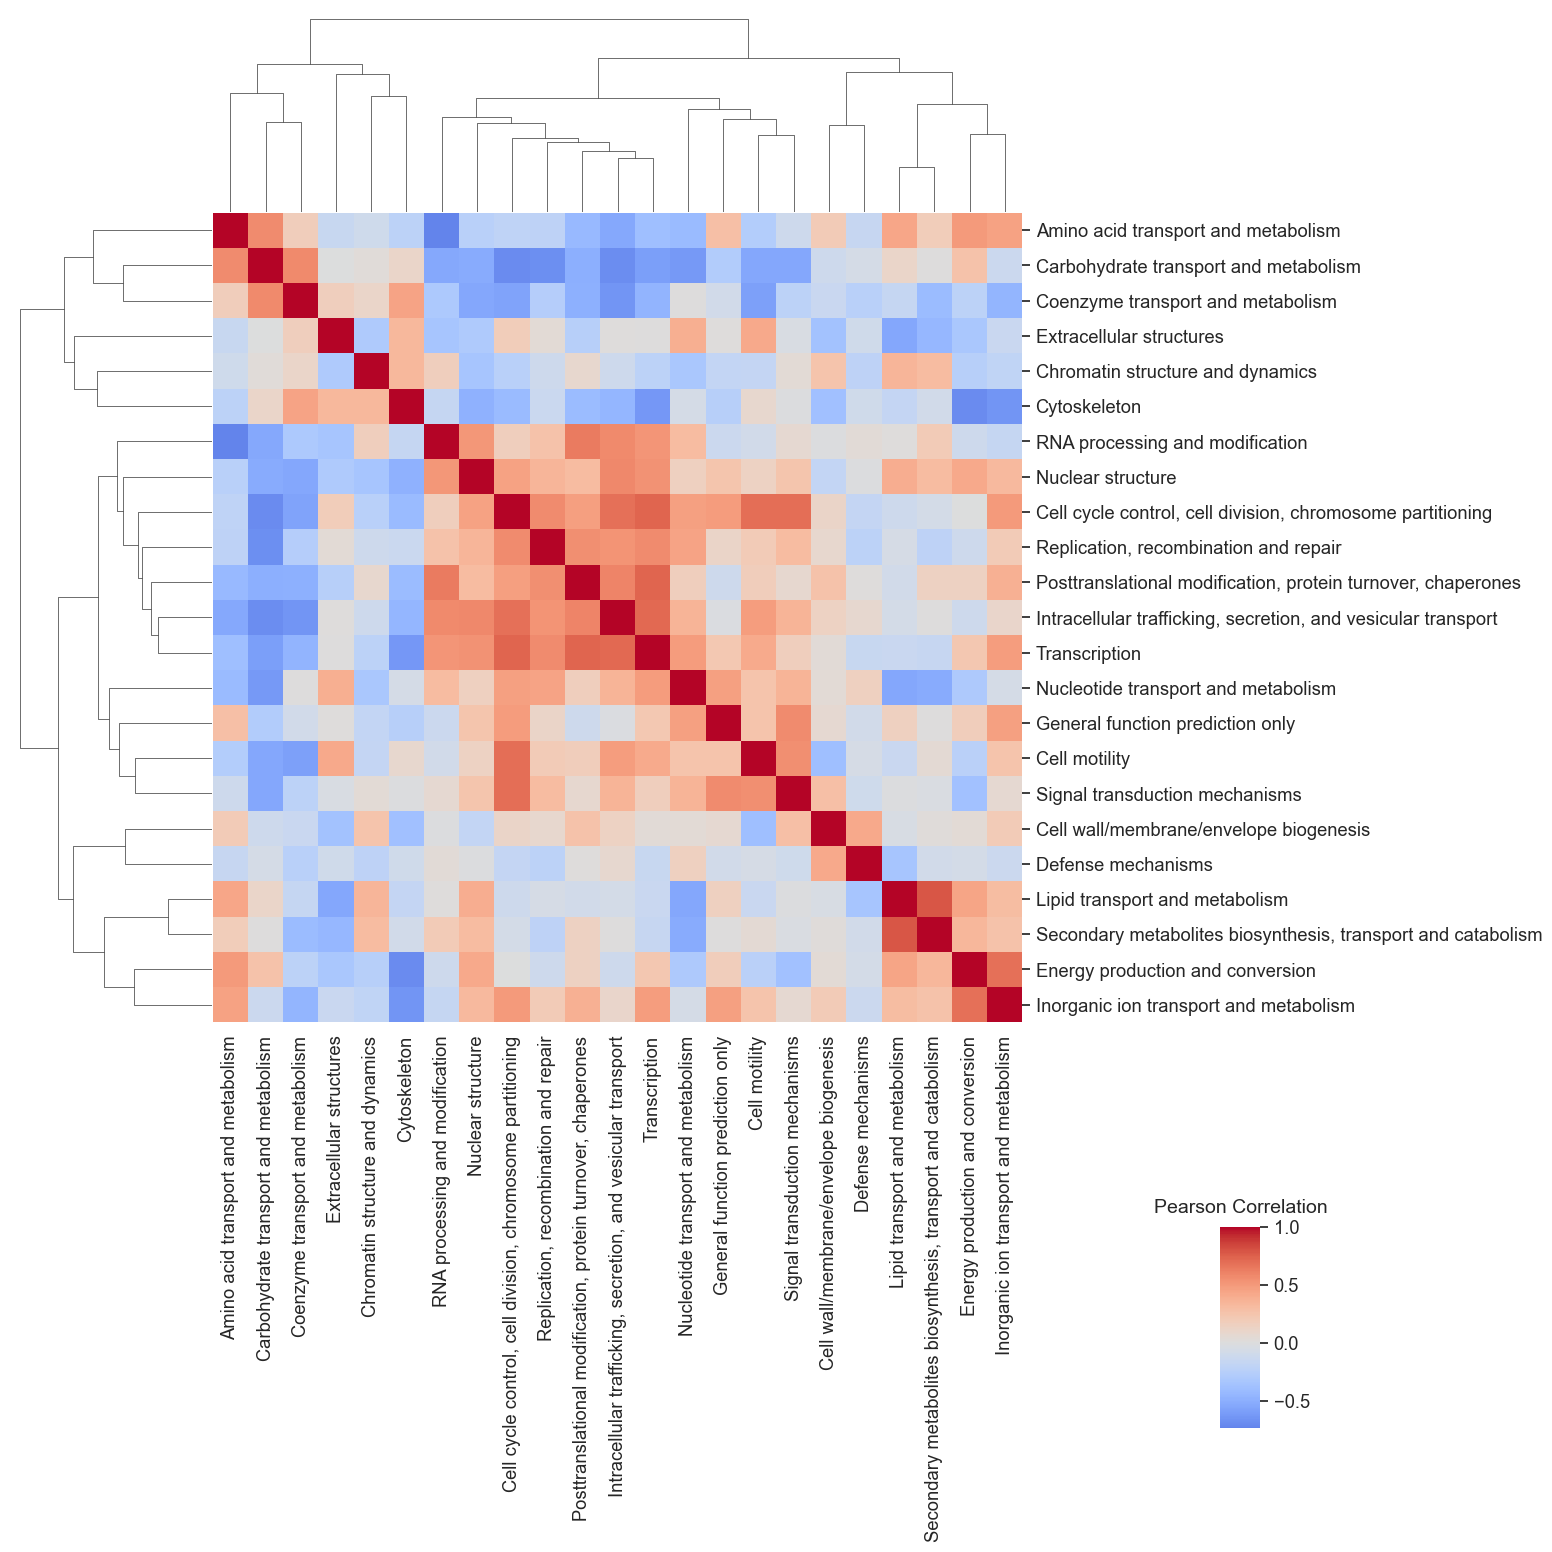

In [53]:
# Plot the correlation between expression of GO slim categories
sns.set(font_scale=1.2)

# Compute the correlation matrix
correlation_matrix = pivoted_expression_zscore.T.corr()

# Create the clustermap
kws = dict(figsize=(16, 16))
g = sns.clustermap(correlation_matrix, cmap='coolwarm', center=0, **kws)

# Adjust the colorbar position
x0, y0, width, height = g.cbar_pos
g.ax_cbar.set_position([x0 + 0.75, y0 - 0.7, width * 0.5, height * 0.7])  # Adjust to lower right
g.ax_cbar.set_title('Pearson Correlation', fontsize=14, pad=10)  # Adjust title padding with `pad`
g.ax_cbar.tick_params(axis='x', length=5)  # Adjust tick length
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# Save the figure as a SVG file
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_categories_51.svg', format='svg', bbox_inches='tight', dpi=800)
plt.savefig('../figures/metatranscriptomics/genome_resolved/pathway_analysis/KOG_expression_correlation_across_categories_51.png', format='png', bbox_inches='tight', dpi=800)
plt.show()